In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.fft import fft
import argparse

In [2]:
def calculate_phasor(signal, sampling_rate):
    """
    Calculate the phasor (magnitude and phase) of the fundamental frequency component.

    Args:
        signal: Time-domain signal.
        sampling_rate: Sampling rate in Hz.

    Returns:
        Complex phasor representing the fundamental frequency component.
    """
    N = len(signal)
    if N == 0:
        return 0j  # Handle empty signal

    fft_result = fft(signal)
    freq_bins = np.fft.fftfreq(N, 1 / sampling_rate)

    # Assume fundamental frequency is 50 Hz
    fundamental_freq = 50.0
    idx = np.argmin(np.abs(freq_bins - fundamental_freq))
    if idx >= len(fft_result):
        return 0j  # Handle case where index is out of bounds
    magnitude = np.abs(fft_result[idx]) * 2 / N  # Scale for single-sided spectrum
    phase = np.angle(fft_result[idx])
    return magnitude * np.exp(1j * phase)


def calculate_distance(v_se, i_se, v_re, i_re, zline):
    """
    Calculate the apparent impedance from voltage and current phasors.

    Args:
        V_phasor: Voltage phasor.
        I_phasor: Current phasor.

    Returns:
        Complex apparent impedance.
    """
    loc_bi = abs(((v_se - v_re) / zline + i_re) / (i_se + i_re))

    return loc_bi


def calculate_distance_2ph(
    v_se1, i_se1, v_se2, i_se2, v_re1, i_re1, v_re2, i_re2, zline
):
    """
    Calculate the apparent impedance from voltage and current phasors for a 2-phase fault.
    Args:
        v_se1, i_se1: Sending end voltage and current for the first faulted phase.
        v_se2, i_se2: Sending end voltage and current for the second faulted phase.
        v_re1, i_re1: Receiving end voltage and current for the first faulted phase.
        v_re2, i_re2: Receiving end voltage and current for the second faulted phase.
        zline: Line impedance per phase.
    Returns:
        loc_se, loc_re, loc_bi: Fault locations from sending end, receiving end, and bidirectional estimate.
    """
    # Calculate line-to-line quantities
    v_se_ll = v_se1 - v_se2
    i_se_ll = i_se1 - i_se2
    v_re_ll = v_re1 - v_re2
    i_re_ll = i_re1 - i_re2

    # Calculate bidirectional estimate
    loc_bi = abs(((v_se_ll - v_re_ll) / zline + i_re_ll) / (i_se_ll + i_re_ll))

    return loc_bi


def calculate_line_impedance(rline, xline, linelength):
    """
    Calculate the line impedance.

    Args:
        rline: Resistance per unit length.
        xline: Reactance per unit length.
        linelength: Length of the line.

    Returns:
        Complex line impedance.
    """
    return (rline + 1j * xline) * linelength

<>:40: SyntaxWarning: invalid escape sequence '\B'
<>:41: SyntaxWarning: invalid escape sequence '\B'
<>:40: SyntaxWarning: invalid escape sequence '\B'
<>:41: SyntaxWarning: invalid escape sequence '\B'
C:\Users\user\AppData\Local\Temp\ipykernel_7736\2352933891.py:40: SyntaxWarning: invalid escape sequence '\B'
  line_se = "Cub_5\Bus2Line_2_3_b_ai_exp_ct_vt"
C:\Users\user\AppData\Local\Temp\ipykernel_7736\2352933891.py:41: SyntaxWarning: invalid escape sequence '\B'
  line_re = "Cub_3\Bus3Line_2_3_b_ai_exp_ct_vt"


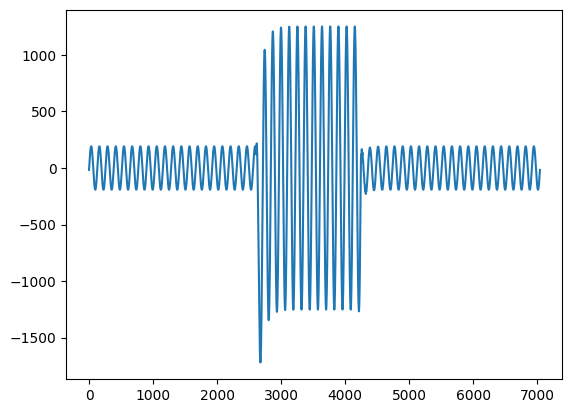

Fault Location for Phases AB: 0.8603
Fault Location for Phases BC: 0.8603
Fault Location for Phases CA: 0.8603
Fault Location Real: 0.8598 3phg, abc


In [4]:
def main():
    """
    Main function to run the distance protection algorithm.

    Args:
        file_path: Path to the measurement file.
        rline: Resistance per unit length.
        xline: Reactance per unit length.
        linelength: Length of the line.
    """
    sampling_rate = 6400

    # 0 = 3ph, 1=2ph, 2=1ph, 3=2phg
    # 0=a/ab, 1=b/bc, 2=c/ca

    # file_path = "r"C:\Users\user\Datasets\new_double_line_90kv_multi_fault_10k\all\replica_1.txt"
    # fault_start = 0.469852118
    # line_se = "Cub_2\Bus2Line_2_3_a_ai_exp_ct_vt"
    # line_re = "Cub_1\Bus3Line_2_3_a_ai_exp_ct_vt"
    # number_fault_phases = 2
    # fault_def = "2phg, bc"
    # line_length = 46.41998737
    # x_line = 0.403900174
    # r_line = 0.05
    # fault_location_real = 87.56495063/100

    # file_path = r"C:\Users\user\Datasets\new_double_line_90kv_multi_fault_10k\all\replica_2.txt"
    # fault_start = 0.385552116
    # line_se = "Cub_2\Bus2Line_2_3_a_ai_exp_ct_vt"
    # line_re = "Cub_1\Bus3Line_2_3_a_ai_exp_ct_vt"
    # number_fault_phases = 1
    # fault_def = "1phg, b"
    # line_length = 38.99641503
    # x_line = 0.395850318
    # r_line = 0.05
    # fault_location_real = 71.87468386/100

    file_path = r"C:\Users\user\Datasets\new_double_line_90kv_multi_fault_10k\all\replica_5.txt"
    fault_start = 0.308236526
    line_se = "Cub_5\Bus2Line_2_3_b_ai_exp_ct_vt"
    line_re = "Cub_3\Bus3Line_2_3_b_ai_exp_ct_vt"
    number_fault_phases = 3
    fault_def = "3phg, abc"
    line_length = 46.76190074
    x_line = 0.409043892
    r_line = 0.05
    fault_location_real = 85.98349053 / 100

    z_line = calculate_line_impedance(r_line, x_line, line_length)

    data = pd.read_csv(
        file_path, delimiter=";", decimal=".", encoding="latin1", header=[0, 1]
    )
    snip_start_idx = int((fault_start + 0.1 + 5 * 0.02) * 6400)

    snip_end_idx = int(snip_start_idx + 0.1 * 6400)
    data_se = data[line_se].iloc[snip_start_idx:snip_end_idx]
    data_re = data[line_re].iloc[snip_start_idx:snip_end_idx]

    plt.plot(data[line_se]["Sekundärstrom L1 in A"])
    plt.show()

    Va_se = data_se["Sekundärspannung L1 in V"].values
    Vb_se = data_se["Sekundärspannung L2 in V"].values
    Vc_se = data_se["Sekundärspannung L3 in V"].values
    Ia_se = data_se["Sekundärstrom L1 in A"].values
    Ib_se = data_se["Sekundärstrom L2 in A"].values
    Ic_se = data_se["Sekundärstrom L3 in A"].values

    Va_re = data_re["Sekundärspannung L1 in V"].values
    Vb_re = data_re["Sekundärspannung L2 in V"].values
    Vc_re = data_re["Sekundärspannung L3 in V"].values
    Ia_re = data_re["Sekundärstrom L1 in A"].values
    Ib_re = data_re["Sekundärstrom L2 in A"].values
    Ic_re = data_re["Sekundärstrom L3 in A"].values

    # Calculate phasors for each phase for se
    V_phasor_a_se = calculate_phasor(Va_se, sampling_rate)
    V_phasor_b_se = calculate_phasor(Vb_se, sampling_rate)
    V_phasor_c_se = calculate_phasor(Vc_se, sampling_rate)
    I_phasor_a_se = calculate_phasor(Ia_se, sampling_rate)
    I_phasor_b_se = calculate_phasor(Ib_se, sampling_rate)
    I_phasor_c_se = calculate_phasor(Ic_se, sampling_rate)

    # # Print magnitude and angle for each phasor
    # print(f"V_phasor_a_se magnitude: {np.abs(V_phasor_a_se)}, angle: {np.angle(V_phasor_a_se)}")
    # print(f"V_phasor_b_se magnitude: {np.abs(V_phasor_b_se)}, angle: {np.angle(V_phasor_b_se)}")
    # print(f"V_phasor_c_se magnitude: {np.abs(V_phasor_c_se)}, angle: {np.angle(V_phasor_c_se)}")
    # print(f"I_phasor_a_se magnitude: {np.abs(I_phasor_a_se)}, angle: {np.angle(I_phasor_a_se)}")
    # print(f"I_phasor_b_se magnitude: {np.abs(I_phasor_b_se)}, angle: {np.angle(I_phasor_b_se)}")
    # print(f"I_phasor_c_se magnitude: {np.abs(I_phasor_c_se)}, angle: {np.angle(I_phasor_c_se)}")

    # Calculate phasors for each phase for re
    V_phasor_a_re = calculate_phasor(Va_re, sampling_rate)
    V_phasor_b_re = calculate_phasor(Vb_re, sampling_rate)
    V_phasor_c_re = calculate_phasor(Vc_re, sampling_rate)
    I_phasor_a_re = calculate_phasor(Ia_re, sampling_rate)
    I_phasor_b_re = calculate_phasor(Ib_re, sampling_rate)
    I_phasor_c_re = calculate_phasor(Ic_re, sampling_rate)

    # Calculate fault_locations
    if number_fault_phases < 2:
        loc_bi_a = calculate_distance(
            V_phasor_a_se, I_phasor_a_se, V_phasor_a_re, I_phasor_a_re, z_line
        )
        loc_bi_b = calculate_distance(
            V_phasor_b_se, I_phasor_b_se, V_phasor_b_re, I_phasor_b_re, z_line
        )
        loc_bi_c = calculate_distance(
            V_phasor_c_se, I_phasor_c_se, V_phasor_c_re, I_phasor_c_re, z_line
        )

        # Pretty print the results
        print(f"Fault Location for Phase A: BI Location: {loc_bi_a:.4f}")
        print(f"Fault Location for Phase B: BI Location: {loc_bi_b:.4f}")
        print(f"Fault Location for Phase C: BI Location: {loc_bi_c:.4f}")
        print(f"Fault Location Real: {fault_location_real:.4f}", fault_def)
    else:
        loc_bi_ab = calculate_distance_2ph(
            V_phasor_a_se,
            I_phasor_a_se,
            V_phasor_b_se,
            I_phasor_b_se,
            V_phasor_a_re,
            I_phasor_a_re,
            V_phasor_b_re,
            I_phasor_b_re,
            z_line,
        )
        loc_bi_bc = calculate_distance_2ph(
            V_phasor_b_se,
            I_phasor_b_se,
            V_phasor_c_se,
            I_phasor_c_se,
            V_phasor_b_re,
            I_phasor_b_re,
            V_phasor_c_re,
            I_phasor_c_re,
            z_line,
        )
        loc_bi_ca = calculate_distance_2ph(
            V_phasor_c_se,
            I_phasor_c_se,
            V_phasor_a_se,
            I_phasor_a_se,
            V_phasor_c_re,
            I_phasor_c_re,
            V_phasor_a_re,
            I_phasor_a_re,
            z_line,
        )

        print(f"Fault Location for Phases AB: {loc_bi_ab:.4f}")
        print(f"Fault Location for Phases BC: {loc_bi_bc:.4f}")
        print(f"Fault Location for Phases CA: {loc_bi_ca:.4f}")
        print(f"Fault Location Real: {fault_location_real:.4f}", fault_def)


if __name__ == "__main__":
    main()